### What is 2d histogram:
* a  graph that shows the distribution of data for 2 variables
* the brighter the color, the higher the  distribution

### TSKK:
* data visualization - for patterns  or trends
* feature extraction - can extract parts of image with specific color or texture
* image comparison - compare similarities between images

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from core.entities.constants import Paths as p


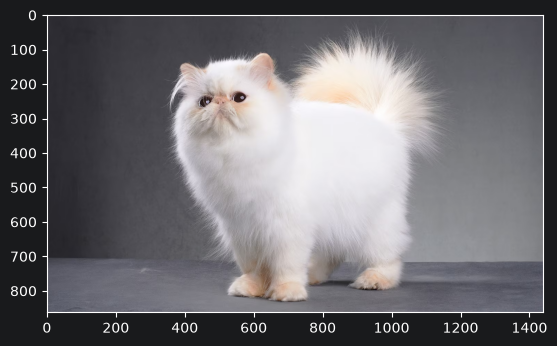

In [2]:
img_path = p.IMAGE_ASSETS / "cat1.png"
img = cv2.imread(img_path, cv2.IMREAD_COLOR_RGB)
plt.figure()
plt.imshow(img)

Text(0.5, 0, 'Saturation')

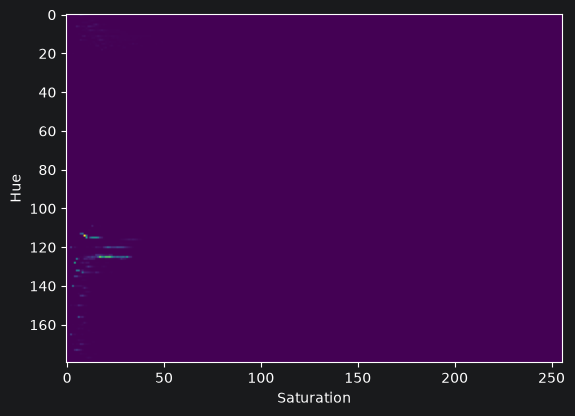

In [3]:
hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

hist = cv2.calcHist([hsv], [0, 1], None, [180, 256], [0, 180, 0, 256])

plt.figure()
plt.imshow(hist)
plt.ylabel("Hue")
plt.xlabel("Saturation")

### visual analyze

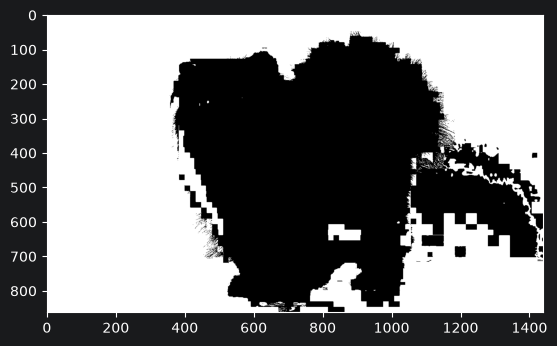

In [4]:
lower_bound = np.array([110, 10, 0])
upper_bound = np.array([130, 130, 255])

mask = cv2.inRange(hsv, lower_bound, upper_bound)
plt.figure()
plt.imshow(mask,cmap="gray")

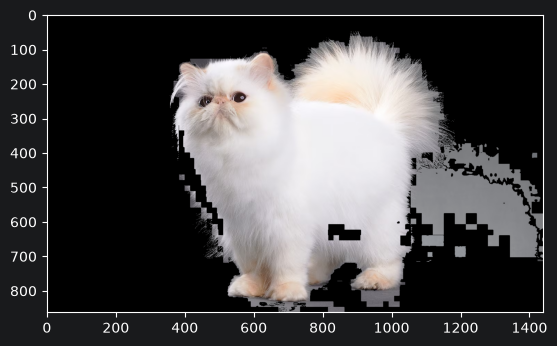

In [5]:
img_masked = np.where(~mask[..., np.newaxis], img, 0)
plt.figure()
plt.imshow(img_masked)

### automatically analyze

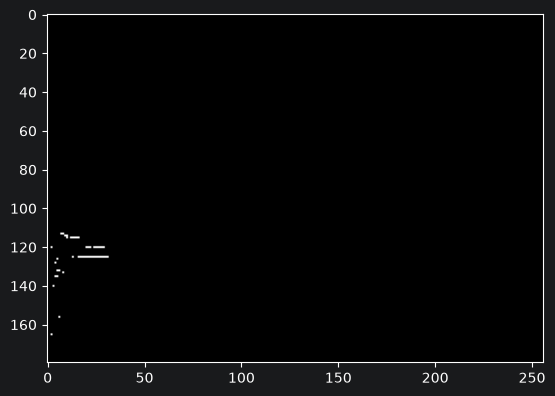

In [6]:
hist_mask = (hist > np.quantile(hist, 0.999)).astype(np.uint8) * 255
plt.figure()
plt.imshow(hist_mask, cmap="gray")

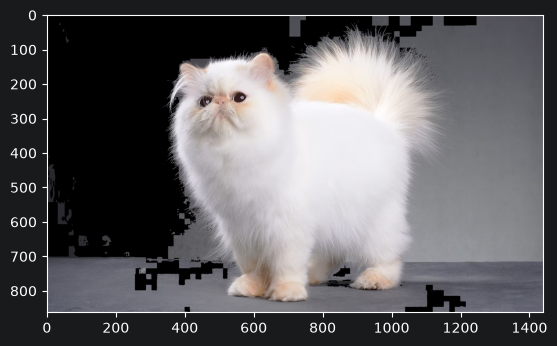

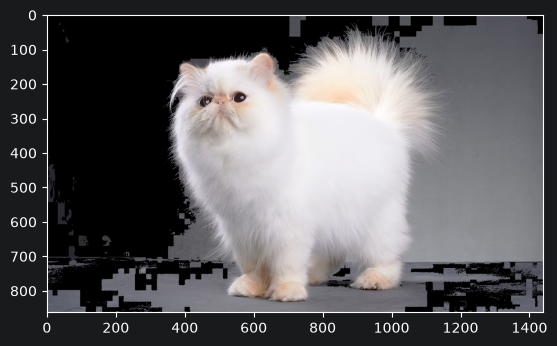

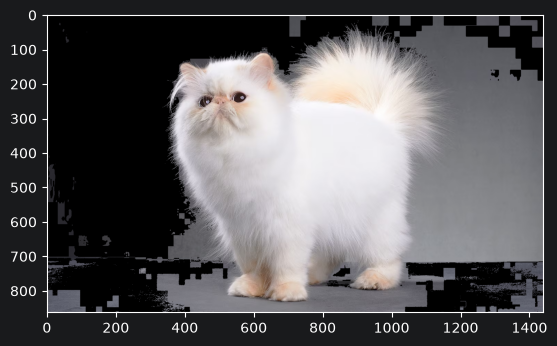

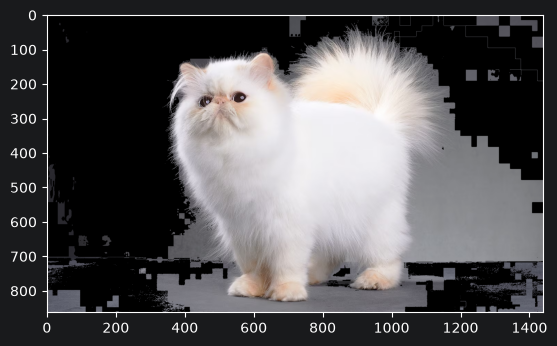

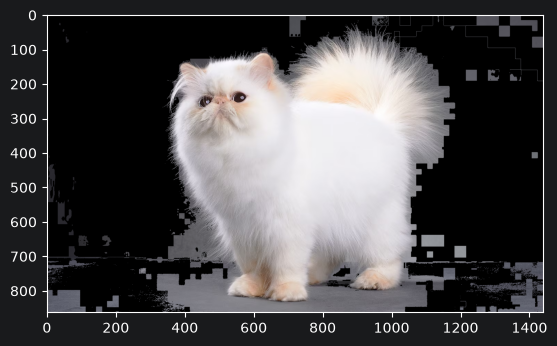

In [7]:
contours, _ = cv2.findContours(hist_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cumulative_mask = np.zeros(img.shape[:2], dtype=np.uint8)
masked_img = img.copy()

for i, cnt in enumerate(contours):
    # contours returns coords (X, Y)
    # for histogram coords X is Value (cols) and Y is Hue (rows)

    # boundingBox returns: x_min, y_min, width, height
    s_min, h_min, s_w, h_h = cv2.boundingRect(cnt)

    area = s_w * h_h

    if area <= 2:
        continue

    s_max = s_min + s_w
    h_max = h_min + h_h

    lower_bound = np.array([h_min, s_min, 0])
    upper_bound = np.array([h_max, s_max, 255])

    cluster_mask = cv2.inRange(hsv, lower_bound, upper_bound)

    masked_img = cv2.bitwise_and(masked_img, masked_img, mask=~cluster_mask)

    plt.figure()
    plt.imshow(masked_img)


### Manual with trackbar

In [8]:
def hsv_mask_callback(value: int):
    pass

In [9]:
window_name = "hsv mask"
cv2.namedWindow(window_name)

cv2.createTrackbar("Hue lower", window_name, 0, 180, hsv_mask_callback)
cv2.createTrackbar("Hue upper", window_name, 180, 180, hsv_mask_callback)
cv2.createTrackbar("S lower", window_name, 0, 255, hsv_mask_callback)
cv2.createTrackbar("S upper", window_name, 255, 255, hsv_mask_callback)
cv2.createTrackbar("V lower", window_name, 0, 255, hsv_mask_callback)
cv2.createTrackbar("V upper", window_name, 255, 255, hsv_mask_callback)

In [10]:
while True:

    h_lower = cv2.getTrackbarPos("Hue lower", window_name)
    h_upper = cv2.getTrackbarPos("Hue upper", window_name)
    s_lower = cv2.getTrackbarPos("S lower", window_name)
    s_upper = cv2.getTrackbarPos("S upper", window_name)
    v_lower = cv2.getTrackbarPos("V lower", window_name)
    v_upper = cv2.getTrackbarPos("V upper", window_name)

    lower_bound = np.array([h_lower, s_lower, v_lower])
    upper_bound = np.array([h_upper, s_upper, v_upper])
    mask = cv2.inRange(hsv, lower_bound, upper_bound)

    cv2.imshow(window_name, mask)

    if cv2.waitKey(1) == ord('q'):

        break

cv2.destroyAllWindows()

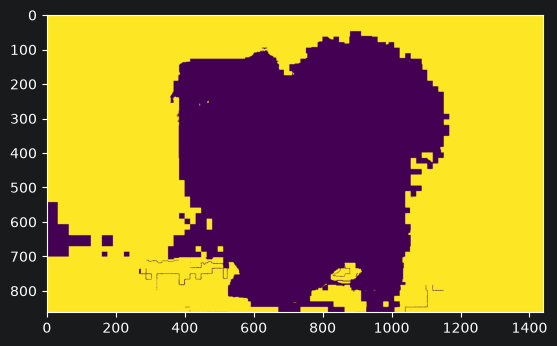

In [11]:
plt.figure()
plt.imshow(mask)

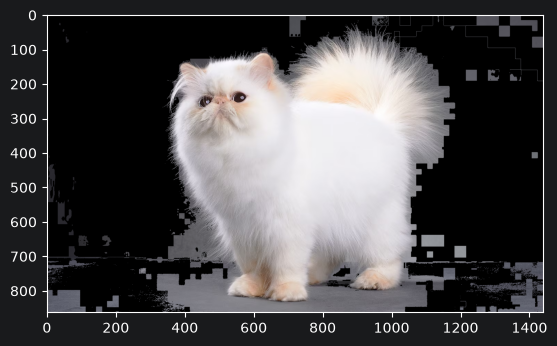

In [12]:
masked_img2 = img.copy()

masked_img2 = cv2.bitwise_and(masked_img2, masked_img2, mask=~mask)
plt.figure()
plt.imshow(masked_img)